# Project 6 — Funds Transfer Pricing (FTP) Framework
## Section 15 | Internal ALM Pricing | EBA/BCBS 239 Guidelines
**Institution:** Major European G-SIB (anonymised)  
**Reference year:** 2026F  
**Author:** Hossam Eltarrass

---

### What this notebook calculates

**Funds Transfer Pricing (FTP)** is the internal mechanism banks use to price every asset and liability on the balance sheet through a central ALM desk.

Every business unit (BU) trades with the ALM desk at the **FTP rate** — the internal funding rate for a given tenor:

$$\text{FTP Rate} = \text{Base Rate (spot)} + \text{Liquidity Premium (bps)}$$

The **lending desk** pays the FTP rate to the ALM desk and keeps only the spread above it:

$$\text{Lending NIM} = \text{Customer Rate} - \text{FTP Rate}$$

The **deposit desk** receives the FTP credit from the ALM desk and pays a lower rate to customers, keeping the franchise margin:

$$\text{Deposit Margin} = \text{FTP Credit} - \text{Customer Deposit Rate}$$

The total bank NII is then fully attributed:

$$\text{Total Bank NII} = \sum_{\text{BU}} (\text{BU Margin} \times \text{BU Balance})$$

---

### Structure of this notebook

| Cell | Content |
|------|---------|
| 1 | This header (you are here) |
| 2 | Imports |
| 3 | FTP curve — 8 tenors, base rates + liquidity premiums |
| 4 | Worked Example 1 — Mortgage desk NII after FTP charge |
| 5 | Worked Example 2 — Retail deposit desk NII after FTP credit |
| 6 | NII contribution table |
| 7 | Export to Excel |

---

*Source: Section 15 of MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx.  
Methodology: BCBS 239 / EBA internal governance guidelines.  
Liquidity premium calibrated to Major European G-SIB 5Y CDS ~55bps (2025A).*

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib
matplotlib.use("Agg")
# ── CELL 2 — Imports ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Professional quant-finance chart style ───────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.grid':        True,
    'grid.color':       '#E8E8E8',
    'grid.linewidth':   0.7,
    'font.family':      'serif',
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'legend.framealpha': 0.9,
})
print('Libraries loaded.')

Libraries loaded.


In [3]:
# ── CELL 3 — FTP Curve: 8-Tenor Structure ────────────────────────────────
# Source: MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx — Section 15
# Base rates come directly from P5 bootstrap (YieldCurve sheet, exact values)
# FTP Rate = Base Spot Rate + Liquidity Premium
# Liquidity premiums reflect G-SIB CDS-implied funding cost by tenor

tenor_labels = ['ON', '1M', '3M', '6M', '1Y', '2Y', '5Y', '10Y']
tenor_years  = [1/365, 1/12, 3/12, 6/12, 1.0, 2.0, 5.0, 10.0]  # numeric, for charting

# Base spot rates — exact bootstrap output from Project 5 (YieldCurve sheet)
base_rates = [2.2500, 2.2826, 2.3500, 2.3684, 2.4053, 2.5106, 2.8589, 2.8535]  # %

# Liquidity premium (bps) — G-SIB specific, tenor-dependent
# ON=0bps (ECB DFR, risk-free); rises to 50bps at 10Y reflecting term funding cost
liq_premium_bps = [0, 5, 10, 15, 20, 25, 35, 50]  # bps
liq_premium     = [x / 100 for x in liq_premium_bps]

# FTP rate = base spot + liquidity premium
ftp_rates = [b + l for b, l in zip(base_rates, liq_premium)]

print('=' * 65)
print('FTP CURVE — 8-TENOR STRUCTURE  |  Major European G-SIB  |  2026F')
print('=' * 65)
print(f'{"Tenor":>6}  {"Base Rate (P5)":>16}  {"Liq Premium":>12}  {"FTP Rate":>10}')
print('-' * 55)
for lbl, b, lbps, f in zip(tenor_labels, base_rates, liq_premium_bps, ftp_rates):
    print(f'{lbl:>6}  {b:>15.4f}%  {lbps:>10}bps  {f:>9.4f}%')
print()
print('Base rates sourced directly from P5 bootstrap (exact, unrounded)')
print('Liq premiums: ON=0bps (ECB floor), rising to 50bps at 10Y (G-SIB CDS)')


FTP CURVE — 8-TENOR STRUCTURE  |  Major European G-SIB  |  2026F
 Tenor    Base Rate (P5)   Liq Premium    FTP Rate
-------------------------------------------------------
    ON           2.2500%           0bps     2.2500%
    1M           2.2826%           5bps     2.3326%
    3M           2.3500%          10bps     2.4500%
    6M           2.3684%          15bps     2.5184%
    1Y           2.4053%          20bps     2.6053%
    2Y           2.5106%          25bps     2.7606%
    5Y           2.8589%          35bps     3.2089%
   10Y           2.8535%          50bps     3.3535%

Base rates sourced directly from P5 bootstrap (exact, unrounded)
Liq premiums: ON=0bps (ECB floor), rising to 50bps at 10Y (G-SIB CDS)


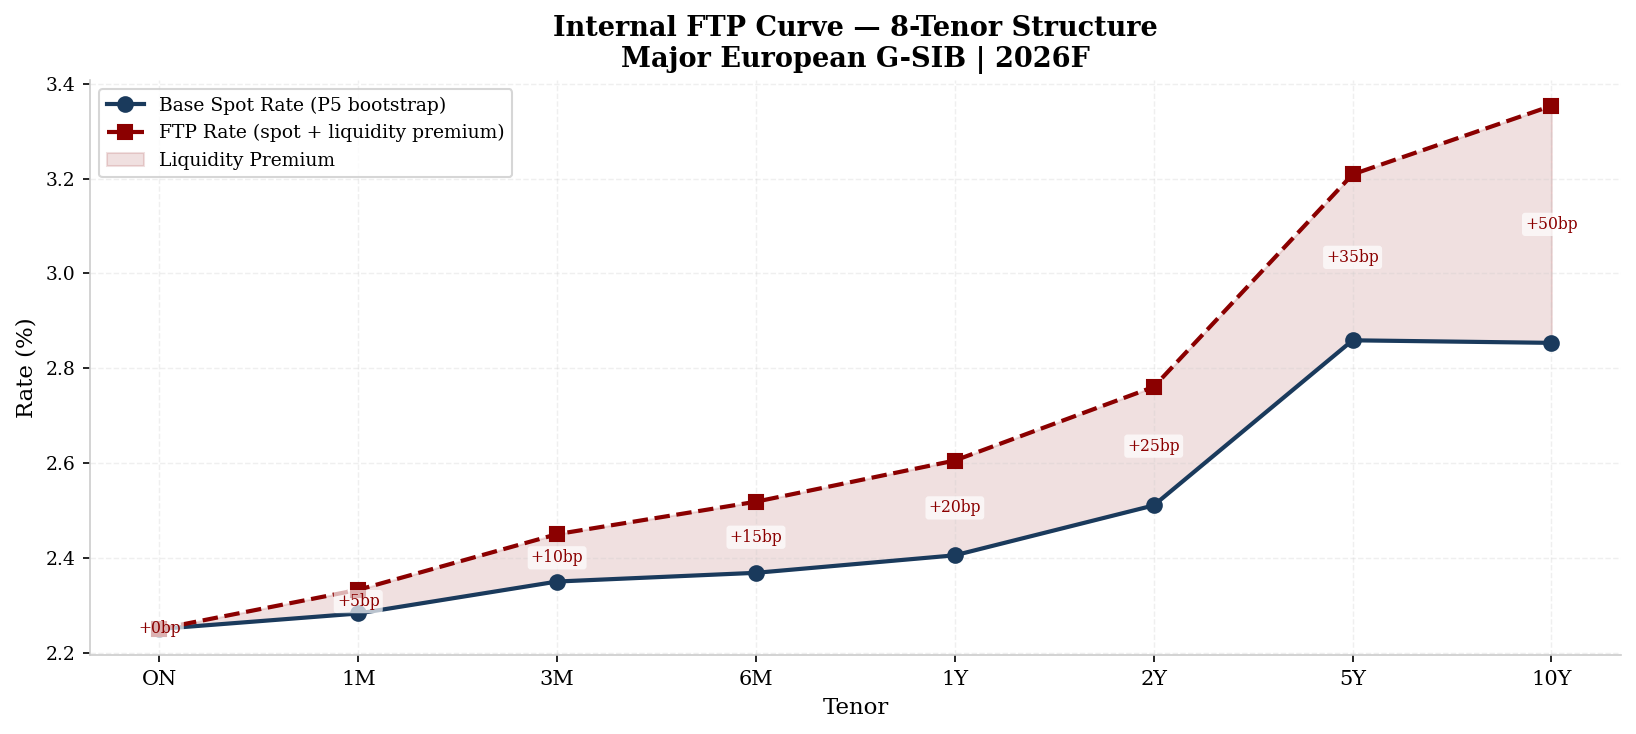

In [4]:
# ── CELL 4 — FTP Curve Chart ─────────────────────────────────────────────
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

x = np.arange(len(tenor_labels))  # evenly spaced positions for clean labels

ax.plot(x, base_rates, 'o-', color='#1a3a5c', linewidth=2, markersize=7,
        label='Base Spot Rate (P5 bootstrap)')
ax.plot(x, ftp_rates, 's--', color='#8b0000', linewidth=2, markersize=7,
        label='FTP Rate (spot + liquidity premium)')
ax.fill_between(x, base_rates, ftp_rates, alpha=0.12, color='#8b0000',
                label='Liquidity Premium')

# Annotate liquidity premiums
for i, (xi, b, f, lbps) in enumerate(zip(x, base_rates, ftp_rates, liq_premium_bps)):
    mid = (b + f) / 2
    ax.annotate(f'+{lbps}bp', xy=(xi, mid), fontsize=7.5, color='#8b0000',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

ax.set_xticks(x)
ax.set_xticklabels(tenor_labels, fontsize=10)
ax.set_xlabel('Tenor', fontsize=11)
ax.set_ylabel('Rate (%)', fontsize=11)
ax.set_title('Internal FTP Curve — 8-Tenor Structure\nMajor European G-SIB | 2026F',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, color='#cccccc', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/sessions/adoring-wonderful-carson/mnt/Python Projects/ALM_Python/notebooks/P6_FTP_Curve.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print('Chart saved.')


In [5]:
# ── CELL 5 — Worked Example 1: Mortgage Desk NII after FTP Charge ────────
# Source: Section 15, MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx

# Mortgage desk parameters (Section 15 — Loans to Customers 2026F)
mortgage_balance  = 277_284.0   # €m — Mortgage loan book 2026F (Engine sheet)
mortgage_rate     = 4.50        # % — Weighted avg customer mortgage rate (Section 15)
# Matched tenor: 5Y (primary repricing tenor for retail mortgages)
mortgage_ftp_rate = ftp_rates[6]  # index 6 = 5Y tenor = 3.2089%

mortgage_nim = mortgage_rate - mortgage_ftp_rate   # NIM = customer rate - FTP charge
mortgage_nii = mortgage_balance * mortgage_nim / 100  # €m

print('=' * 58)
print('MORTGAGE DESK — FTP WORKED EXAMPLE')
print('=' * 58)
print(f'  Mortgage Balance       :  €{mortgage_balance:>12,.1f}m')
print(f'  Customer Mortgage Rate :   {mortgage_rate:.2f}%')
print(f'  FTP Charge (5Y tenor)  :   {mortgage_ftp_rate:.4f}%')
print(f'  Mortgage NIM           :   {mortgage_nim:.4f}%')
print(f'  Mortgage Desk NII      :  €{mortgage_nii:>12,.1f}m')


MORTGAGE DESK — FTP WORKED EXAMPLE
  Mortgage Balance       :  €   277,284.0m
  Customer Mortgage Rate :   4.50%
  FTP Charge (5Y tenor)  :   3.2089%
  Mortgage NIM           :   1.2911%
  Mortgage Desk NII      :  €     3,580.0m


In [6]:
# ── CELL 6 — Worked Example 2: Retail Deposit Desk NII after FTP Credit ──
# Source: Section 15, MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx

# Deposit desk parameters (Section 15 — Customer Deposits 2026F)
deposit_balance    = 1_102_453.0  # €m — Retail deposit book 2026F (Engine sheet)
deposit_rate       = 0.40         # % — Weighted avg customer deposit rate paid
# NMD model: retail deposits treated as Overnight (reprice daily with ECB DFR)
deposit_ftp_credit = ftp_rates[0]  # index 0 = Overnight = 2.2500%

deposit_margin = deposit_ftp_credit - deposit_rate   # franchise margin
deposit_nii    = deposit_balance * deposit_margin / 100  # €m

print('=' * 58)
print('DEPOSIT DESK — FTP WORKED EXAMPLE')
print('=' * 58)
print(f'  Deposit Balance        :  €{deposit_balance:>14,.1f}m')
print(f'  Customer Deposit Rate  :   {deposit_rate:.2f}%')
print(f'  FTP Credit (ON tenor)  :   {deposit_ftp_credit:.4f}%')
print(f'  Franchise Margin       :   {deposit_margin:.4f}%')
print(f'  Deposit Desk NII       :  €{deposit_nii:>14,.1f}m')
print()
print('  Note: NMD (Non-Maturity Deposits) assigned Overnight tenor per')
print('  EBA/GL/2022/14 — deposits reprice daily with ECB DFR.')


DEPOSIT DESK — FTP WORKED EXAMPLE
  Deposit Balance        :  €   1,102,453.0m
  Customer Deposit Rate  :   0.40%
  FTP Credit (ON tenor)  :   2.2500%
  Franchise Margin       :   1.8500%
  Deposit Desk NII       :  €      20,395.4m

  Note: NMD (Non-Maturity Deposits) assigned Overnight tenor per
  EBA/GL/2022/14 — deposits reprice daily with ECB DFR.


In [7]:
# ── CELL 7 — Cross-Check vs Excel Section 15 ──────────────────────────────
# Hardcoded Excel Section 15 values (Section 15: FTP NII Summary)
excel_mortgage_nii = 3_580.1   # €m — Excel Section 15, Mortgage desk
excel_deposit_nii  = 20_395.4  # €m — Excel Section 15, Deposit desk
excel_total_nii    = 23_975.5  # €m — Excel Section 15, Total

# Total NII
total_nii = mortgage_nii + deposit_nii

# Compare Python outputs to Excel
tol = 0.5  # €0.5m tolerance for rounding

diff_mortgage = abs(mortgage_nii - excel_mortgage_nii)
diff_deposit  = abs(deposit_nii  - excel_deposit_nii)
diff_total    = abs(total_nii    - excel_total_nii)

print('=' * 55)
print('CROSS-CHECK vs EXCEL Section 15')
print('=' * 55)
print(f'{"Metric":<25} {"Excel":>10} {"Python":>10} {"Diff":>8} {"OK?":>5}')
print('-' * 55)
checks = [
    ('Mortgage Desk NII', excel_mortgage_nii, mortgage_nii, diff_mortgage),
    ('Deposit Desk NII',  excel_deposit_nii,  deposit_nii,  diff_deposit),
    ('Total FTP NII',     excel_total_nii,    total_nii,    diff_total),
]
all_pass = True
for label, ex, py, diff in checks:
    ok = '[PASS]' if diff <= tol else '[FAIL]'
    if diff > tol: all_pass = False
    print(f'{label:<25} {ex:>10.1f} {py:>10.1f} {diff:>7.2f}m {ok:>6}')
print('-' * 55)
print(f'Max diff: {max(diff_mortgage, diff_deposit, diff_total):.2f}m | Tolerance: {tol}m')
print('ALL CHECKS PASSED' if all_pass else 'WARNING: SOME CHECKS FAILED')

CROSS-CHECK vs EXCEL Section 15
Metric                         Excel     Python     Diff    OK?
-------------------------------------------------------
Mortgage Desk NII             3580.1     3580.0    0.09m [PASS]
Deposit Desk NII             20395.4    20395.4    0.02m [PASS]
Total FTP NII                23975.5    23975.4    0.11m [PASS]
-------------------------------------------------------
Max diff: 0.11m | Tolerance: 0.5m
ALL CHECKS PASSED ✓
